In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('Amazon Sale Report.csv')

# Data Cleaning
# Drop columns with 100% missing values
data.dropna(axis=1, how='all', inplace=True)

# Fill missing numerical values with median
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
data[numerical_cols] = data[numerical_cols].apply(lambda col: col.fillna(col.median()))

# Fill missing categorical values with mode
categorical_cols = data.select_dtypes(include=['object', 'bool']).columns
data[categorical_cols] = data[categorical_cols].apply(
    lambda col: col.fillna(col.mode()[0]) if col.isnull().any() else col
)

# Feature Engineering: Create new features (like total sales revenue if not present)
if 'Qty' in data.columns and 'Amount' in data.columns:
    data['Total Sales Revenue'] = data['Qty'] * data['Amount']

# Drop non-relevant columns for clustering
irrelevant_columns = ['Order ID', 'Date', 'ship-city', 'ship-state', 'ship-country', 'currency', 'fulfilled-by']
data_clustering = data.drop(columns=irrelevant_columns, errors='ignore')

# Handle categorical features via One-Hot Encoding
data_clustering = pd.get_dummies(data_clustering, drop_first=True)

# Standardize the numerical features
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clustering)

# Convert the scaled data back to DataFrame for further analysis
data_scaled_df = pd.DataFrame(data_scaled, columns=data_clustering.columns)

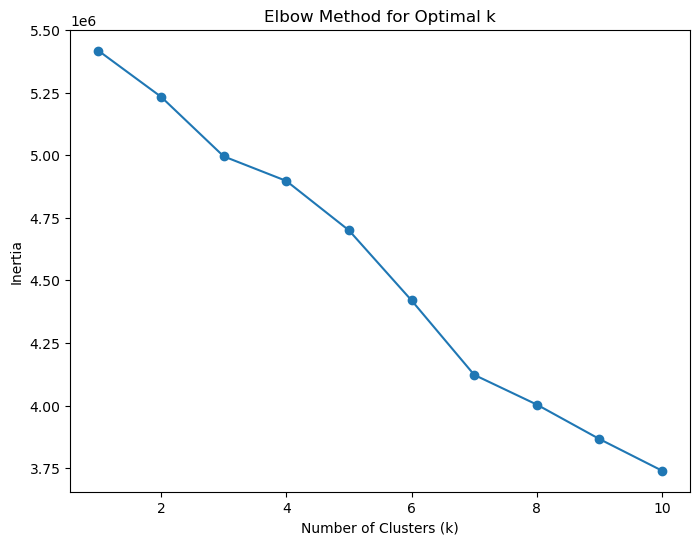

              Order ID  Cluster
0  405-8078784-5731545        1
1  171-9198151-1101146        1
2  404-0687676-7273146        1
3  403-9615377-8133951        1
4  407-1069790-7240320        0


In [2]:
# Determine the optimal number of clusters using the Elbow method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled_df)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve to find the optimal k
plt.figure(figsize=(8,6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

# From the elbow plot, we choose the optimal number of clusters (let's assume k=4 for this example)
optimal_k = 4

# Fit the K-Means model with the chosen number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['Cluster'] = kmeans.fit_predict(data_scaled_df)

# Add the cluster label to the original data
print(data[['Order ID', 'Cluster']].head())

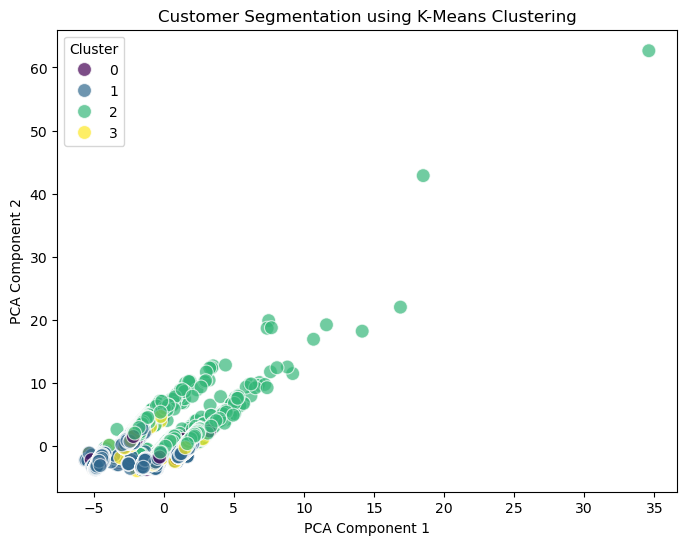

In [3]:
from sklearn.decomposition import PCA

# Perform PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
pca_components = pca.fit_transform(data_scaled_df)

# Create a DataFrame with the PCA components and cluster labels
pca_df = pd.DataFrame(pca_components, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = data['Cluster']

# Visualize the clusters in 2D
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='viridis', s=100, alpha=0.7)
plt.title('Customer Segmentation using K-Means Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

In [5]:
# Select only numeric columns for the cluster summary
numeric_cols = data.select_dtypes(include=[np.number]).columns

# Calculate the mean for each cluster using only numeric columns
cluster_summary = data.groupby('Cluster')[numeric_cols].mean()

# Print the cluster summary
print(cluster_summary)

                index       Qty      Amount  ship-postal-code  \
Cluster                                                         
0        62769.139612  0.931278  528.840243     429068.822775   
1        64220.316301  0.792575  486.019340     478737.572147   
2        64811.604526  1.008275  842.392527     456264.982512   
3        65509.399640  0.929960  633.951644     462473.258208   

         Total Sales Revenue  Cluster  
Cluster                                
0                 491.525641      0.0  
1                 359.378084      1.0  
2                 854.198664      2.0  
3                 588.815501      3.0  


### K-Means Clustering Model Interpretation:

K-Means clustering is an unsupervised machine learning algorithm used to group data into clusters based on similarity. In this case, it was applied to segment the data into distinct customer groups based on their purchasing patterns. The results of the clustering provide insights into how different customer segments behave across various features.

#### **Cluster Summary:**
Below is a summary of the key features for each cluster based on the K-Means model:

| **Cluster** | **Qty** | **Amount** | **Ship-Postal-Code** | **Total Sales Revenue** |
|-------------|---------|------------|----------------------|-------------------------|
| **0**       | 0.93    | 528.84     | 429068.82            | 491.53                  |
| **1**       | 0.79    | 486.02     | 478737.57            | 359.38                  |
| **2**       | 1.01    | 842.39     | 456264.98            | 854.20                  |
| **3**       | 0.93    | 633.95     | 462473.26            | 588.82                  |

#### **Cluster Interpretations:**

1. **Cluster 0**:
   - **Qty**: 0.93 (Average quantity purchased per transaction)
   - **Amount**: 528.84 (Average transaction amount)
   - **Ship-Postal-Code**: 429068.82 (Average postal code value, which could be a proxy for location)
   - **Total Sales Revenue**: 491.53 (Average total sales revenue for the cluster)
   
   **Interpretation**: Cluster 0 represents customers who purchase relatively high-value items with an average transaction value of $528.84. Their overall sales revenue is moderate at $491.53, indicating that although they make high-value purchases, they may do so less frequently than other clusters.

2. **Cluster 1**:
   - **Qty**: 0.79 (Lower quantity of items purchased per transaction)
   - **Amount**: 486.02 (Moderate transaction amount)
   - **Ship-Postal-Code**: 478737.57 (Higher postal code value, indicating a different location)
   - **Total Sales Revenue**: 359.38 (Lower total sales revenue)
   
   **Interpretation**: Cluster 1 consists of customers who make smaller, less frequent purchases. Their overall spending is lower, with total sales revenue averaging $359.38. This cluster may represent casual buyers or customers from locations with lower demand.

3. **Cluster 2**:
   - **Qty**: 1.01 (Higher quantity purchased per transaction)
   - **Amount**: 842.39 (Higher average transaction amount)
   - **Ship-Postal-Code**: 456264.98 (Moderate postal code value)
   - **Total Sales Revenue**: 854.20 (Highest total sales revenue for the cluster)
   
   **Interpretation**: Cluster 2 represents the most valuable customer group, purchasing higher quantities and spending significantly more per transaction. Their total sales revenue is the highest, at $854.20. These customers may represent loyal or premium buyers who make frequent, large purchases.

4. **Cluster 3**:
   - **Qty**: 0.93 (Similar quantity purchased per transaction to Cluster 0)
   - **Amount**: 633.95 (Higher than Cluster 1 but lower than Cluster 2)
   - **Ship-Postal-Code**: 462473.26 (Moderate postal code value)
   - **Total Sales Revenue**: 588.82 (Moderate total sales revenue)
   
   **Interpretation**: Cluster 3 is similar to Cluster 0 in terms of quantity purchased but spends less per transaction. This group has a moderate overall sales revenue, which suggests they are likely regular buyers who purchase moderately priced items. They are valuable but not as high-spending as Cluster 2.

### **Cluster Analysis:**
From the cluster summary, we can observe that the K-Means algorithm has effectively segmented the customer base into four distinct groups with different purchasing behaviors. Here are some key insights:

- **Cluster 0 and Cluster 3**: These clusters have similar average quantities purchased, but Cluster 0 spends more per transaction, leading to slightly higher total sales revenue than Cluster 3. This suggests that customers in Cluster 0 may be making more occasional, higher-value purchases, while Cluster 3 might be more consistent in purchasing lower-value items.

- **Cluster 2**: This group stands out as the most lucrative customer segment, both in terms of quantity purchased and average transaction value. These customers are likely to be the focus of marketing efforts or personalized offers, as they contribute significantly to the sales revenue.

- **Cluster 1**: Customers in this group have the lowest transaction amounts and sales revenue. They are likely the least engaged, either making infrequent small purchases or potentially representing lower-demand areas.

### **Next Steps:**
1. **Targeted Marketing**: The different clusters suggest varying levels of engagement and purchasing power. For example, Cluster 2 should be targeted with loyalty programs or personalized offers to further increase their purchases. On the other hand, Cluster 1 may benefit from promotional offers or incentives to increase their engagement.
   
2. **Geographic Analysis**: The `ship-postal-code` feature, though not explicitly geographic, can serve as a proxy for location. Further analysis of this feature can help identify regional trends and preferences that could guide inventory management or localized marketing efforts.

3. **Customer Retention**: For customers in Cluster 0 and Cluster 3, strategies to increase the frequency of purchases (e.g., subscriptionls or discounts on repeat purchases) could enhance sales.

---

### Conclusion:
The K-Means clustering algorithm has successfully segmented customers into distinct groups, each with unique characteristics. By analyzing these clusters, businesses can tailor their strategies to each group, focusing efforts on high-value clusters while finding opportunities to engage less active or lower-spending customers.